# NEURO 120: song, speech, and instrumental music in human ECoG

**Research question.** In Norman–Haignere et al. (2022), seven electrodes were labelled song-selective. We ask whether those seven carry more song-versus-music information than any other seven electrodes from the non-song pool, or whether their advantage in raw plots is mostly a small-subset effect.

**What this notebook does.** It calls functions in `logic/` and `logic/pipeline.py` in order. A full top-to-bottom run regenerates figures and tables under `results/` that match the write-up, assuming `data/` is laid out as in `data/README.md`.

**Design constraints**

- Cross-validation is grouped by stimulus (`StratifiedGroupKFold`), so no stimulus appears in both train and test.
- Feature scaling is fit on training folds only.
- Randomness uses `config.RANDOM_STATE` everywhere the pipeline exposes a seed.
- We keep the headline negative controls (matched random subsets, nonlinear baselines) in the same flow as the positive results.

**Data summary.** 33 electrodes (7 song-, 15 speech-, 11 music-selective), HFA for 49 stimuli (11 song, 17 speech, 21 music), 0 to 2 s per trial.


## 1. Setup

Imports, add `logic/` to the path, load the Norman–Haignere dataset, and create output folders via `config.ensure_dirs()`. The setup cell also defines `_lap` and `print_run_timings()` so each analysis section records wall time; run the **Timing summary** cell at the very end after a full pass.


In [1]:
# Uncomment if dependencies are missing in this kernel:
# %pip install -r requirements.txt

import importlib
import sys
import time
import warnings
import wave
from pathlib import Path

import numpy as np
from IPython.display import Image, display

# Notebooks are not inside the logic package, so add logic/ to sys.path
# for the same flat imports as python logic/pipeline.py (import config, etc.).
LOGIC_DIR = (Path.cwd() / "logic").resolve()
if str(LOGIC_DIR) not in sys.path:
    sys.path.insert(0, str(LOGIC_DIR))

import config
import data_utils
import pipeline
import rdm
import temporal_profile
from bellier_data import load_vocal_segments
from config import (
    BELLIER_AUDIO_PATH,
    BELLIER_FS,
    BELLIER_T,
    BELLIER_VOCAL_CSV,
    FIG_DIR,
)
from data_utils import build_dataset
from plots import plot_dataset_overview
from subsets import define_fixed_subsets

warnings.filterwarnings("ignore")

# Wall-clock timing for each notebook section (call _lap at end of each block).
_t_mark = time.perf_counter()
_RUN_SECTIONS = []


def _lap(label):
    global _t_mark
    now = time.perf_counter()
    _RUN_SECTIONS.append((label, now - _t_mark))
    _t_mark = now


def print_run_timings():
    if not _RUN_SECTIONS:
        print("No section timings recorded.")
        return
    total = sum(dt for _, dt in _RUN_SECTIONS)
    print("\nSection run times (wall clock)")
    for name, dt in _RUN_SECTIONS:
        print(f"  {name:44s}  {dt:8.2f} s")
    print("  " + "-" * 56)
    print(f"  {'Total':44s}  {total:8.2f} s")


config.ensure_dirs()
ds = build_dataset()
subs = define_fixed_subsets(ds["electrode_group"])
print("meta:", ds["meta"])
_lap("1. Setup and dataset load")


meta: {'n_electrodes': 33, 'n_stimuli': 49, 'n_time': 201, 'dt_s': 0.010000000000000009, 'time_window_s': (0.0, 2.0), 'n_per_group': {'song': 7, 'speech': 15, 'music': 11}, 'n_per_class': {'song': 11, 'speech': 17, 'music': 21}, 'keep_classes': ['song', 'speech', 'music']}


## Figure 1. Dataset and electrode subsets

Stimulus counts by class, electrode counts by selectivity group, and the subsets used later:

- `all`: all 33 electrodes.
- `no_song`: 26 electrodes that are not song-selective (speech + music groups).
- `song_only`: the 7 song-selective electrodes.
- `random`: many random 7-electrode draws from `no_song`. Used as the null for comparing against `song_only` in Section 5.


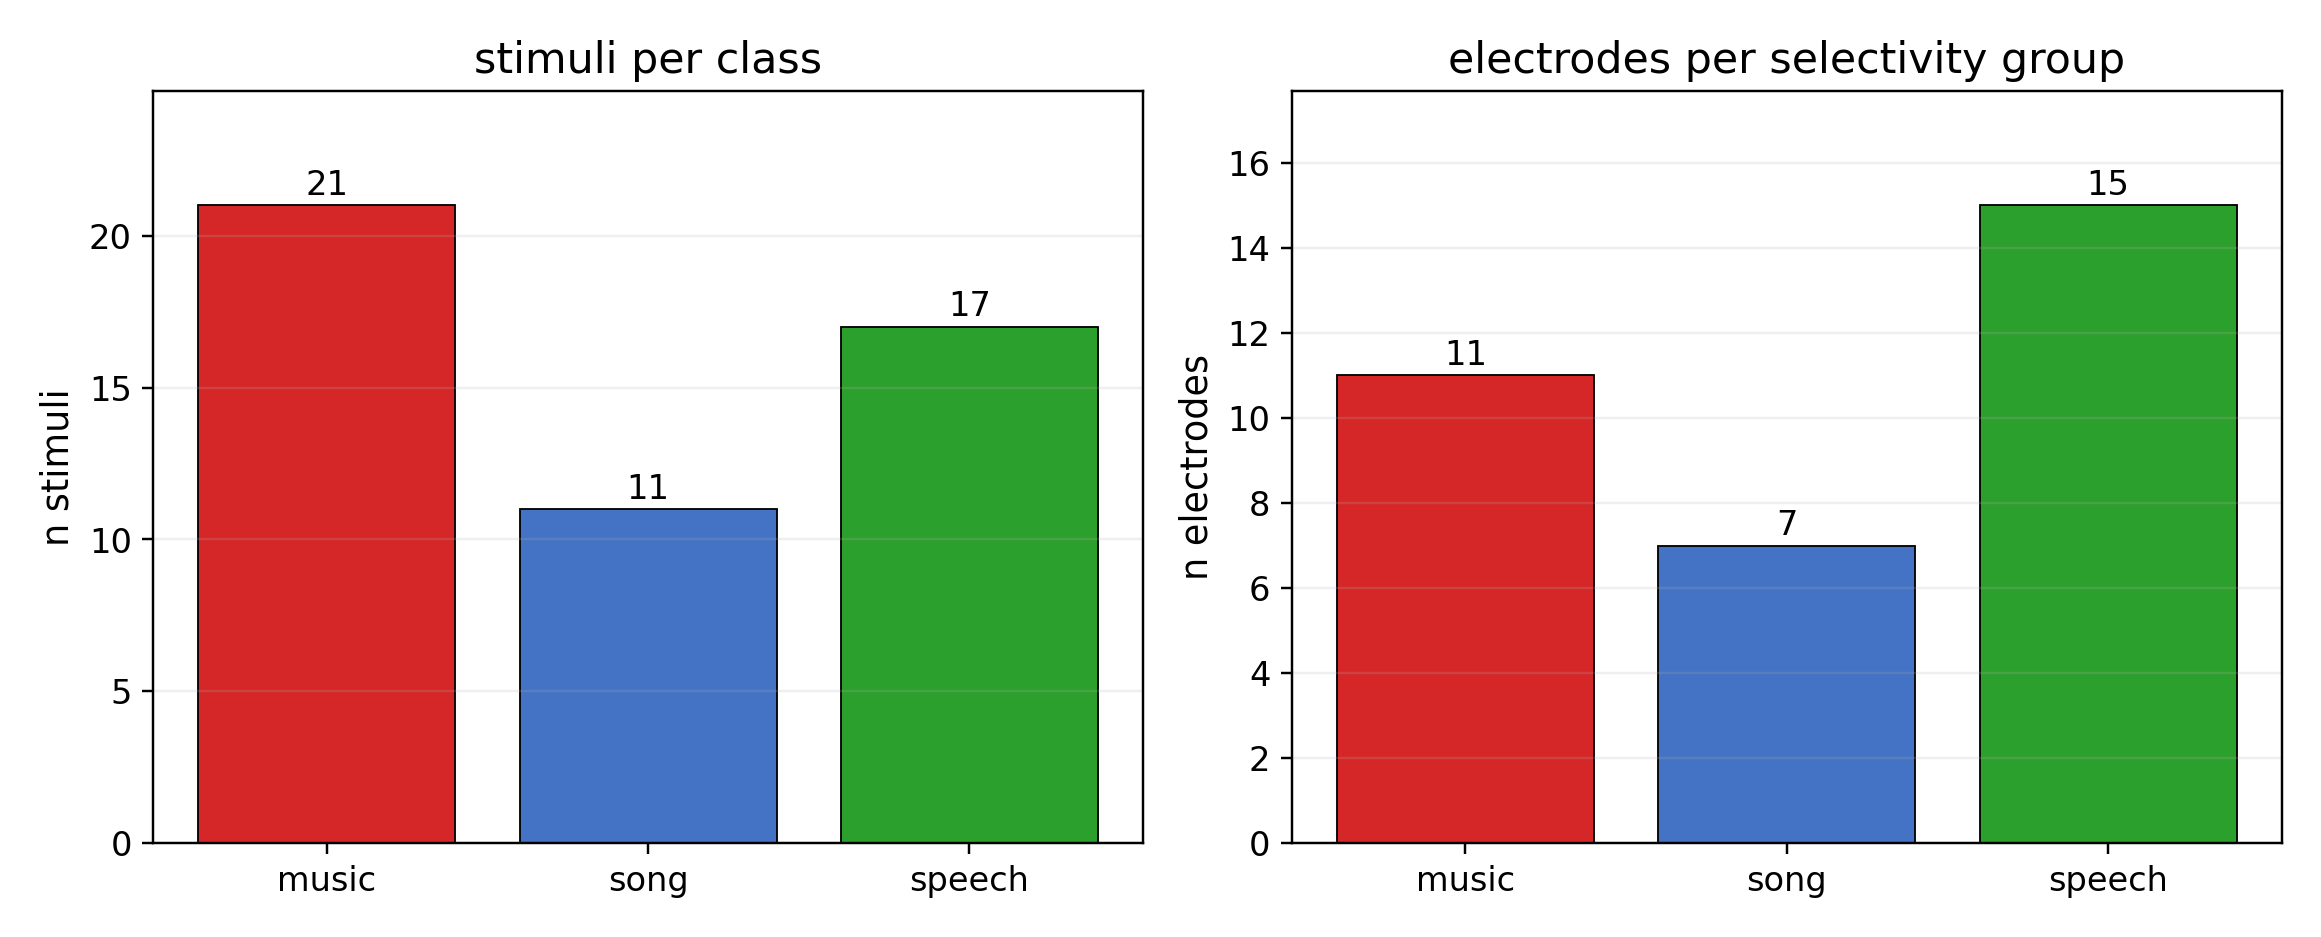

In [2]:
# Saves fig1 to FIG_DIR and shows the PNG saved by the plotting helper.
plot_dataset_overview(ds["meta"], ds["electrode_group"], ds["y_coarse"])
display(Image(filename=str(FIG_DIR / "fig1_dataset_overview.png")))
_lap("Figure 1 dataset overview")


## 2. Baseline three-class decoder (Figure 2)

**Question.** Can a linear decoder separate song, speech, and instrumental music at all?

**Method.** Grouped 5-fold CV, logistic regression on the early-window mean HFA (0.2 to 0.6 s). Outputs balanced accuracy and a row-normalised confusion matrix.

**Readout.** Balanced accuracy should be well above chance (one third). Residual errors should be mostly song versus music confusions, which motivates the later song-versus-music analyses.


,task,window_s,balanced_accuracy,macro_f1,recall_music,recall_song,recall_speech
0,three_class,0.2-0.6,0.969697,0.974603,1.0,0.909091,1.0


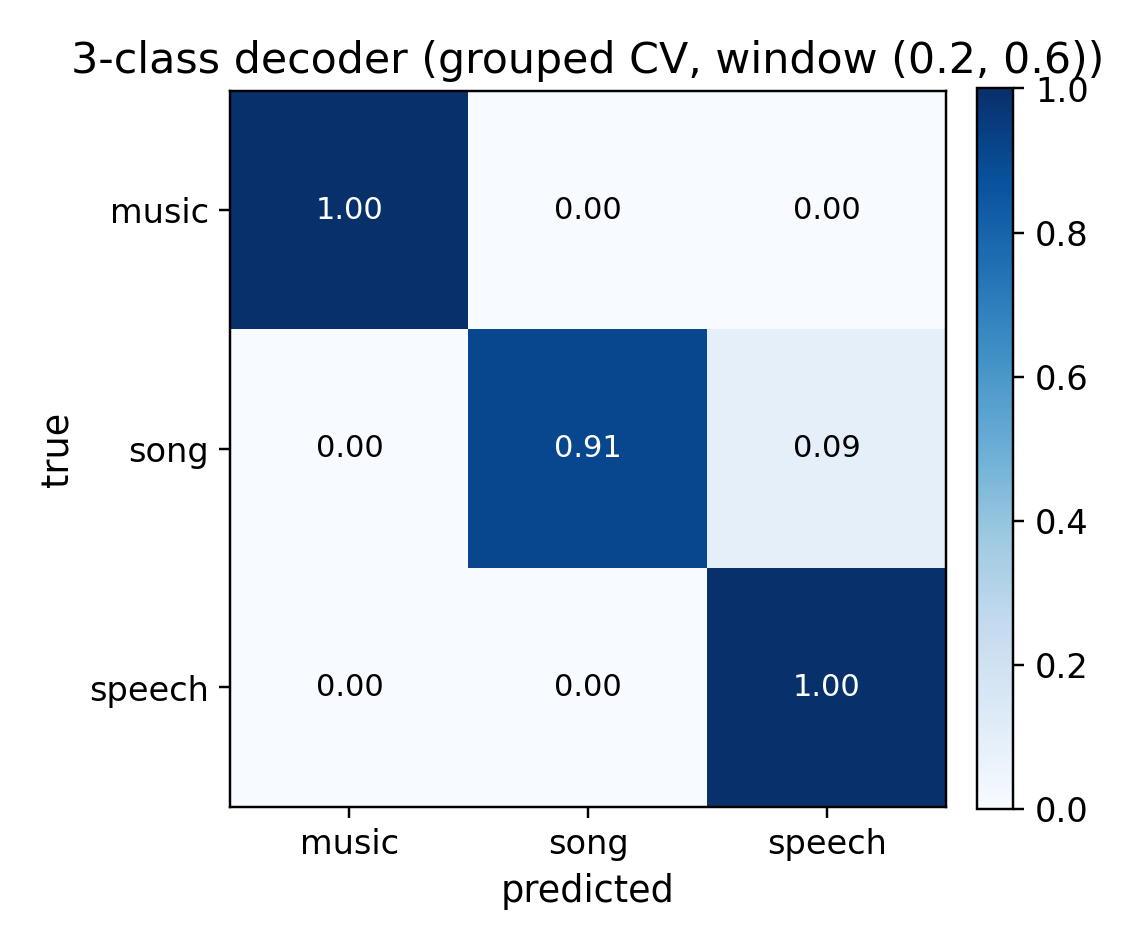

In [3]:
# Grouped CV three-class baseline; writes CSV summary and confusion figure under FIG_DIR.
b = pipeline.run_baseline_3class(ds)
display(b["summary"])
display(Image(filename=str(FIG_DIR / "fig2_baseline_confusion.png")))
_lap("2. Baseline three-class")

**Interpretation.** Performance is high and errors are mainly song versus music. That confirms grouped CV and early-window features behave as expected before we restrict to the song versus music discrimination.


## 3. Time-resolved song versus music decoder (Figure 5)

**Question.** At which times is song decodable from instrumental music, and how do `all`, `no_song`, and `song_only` compare?

**Method.** Sliding windows (150 ms, 50 ms step), grouped CV, binary logistic regression for song versus music on each subset. Shaded bands are bootstrap 95% CIs over stimuli.

**Readout.** Peak height and timing for each curve. A higher `song_only` curve can reflect real information or easier fitting on only seven electrodes. Section 5 tests the latter with a size-matched null.


,subset,peak_bacc,peak_time_s,early_window_mean_bacc,full_window_mean_bacc,mean_auc
0,all,1.000000,0.32,0.925054,0.920711,0.953064
1,no_song,0.954545,0.67,0.861742,0.869162,0.925382
2,song_only,1.000000,0.67,0.895563,0.917179,0.951697


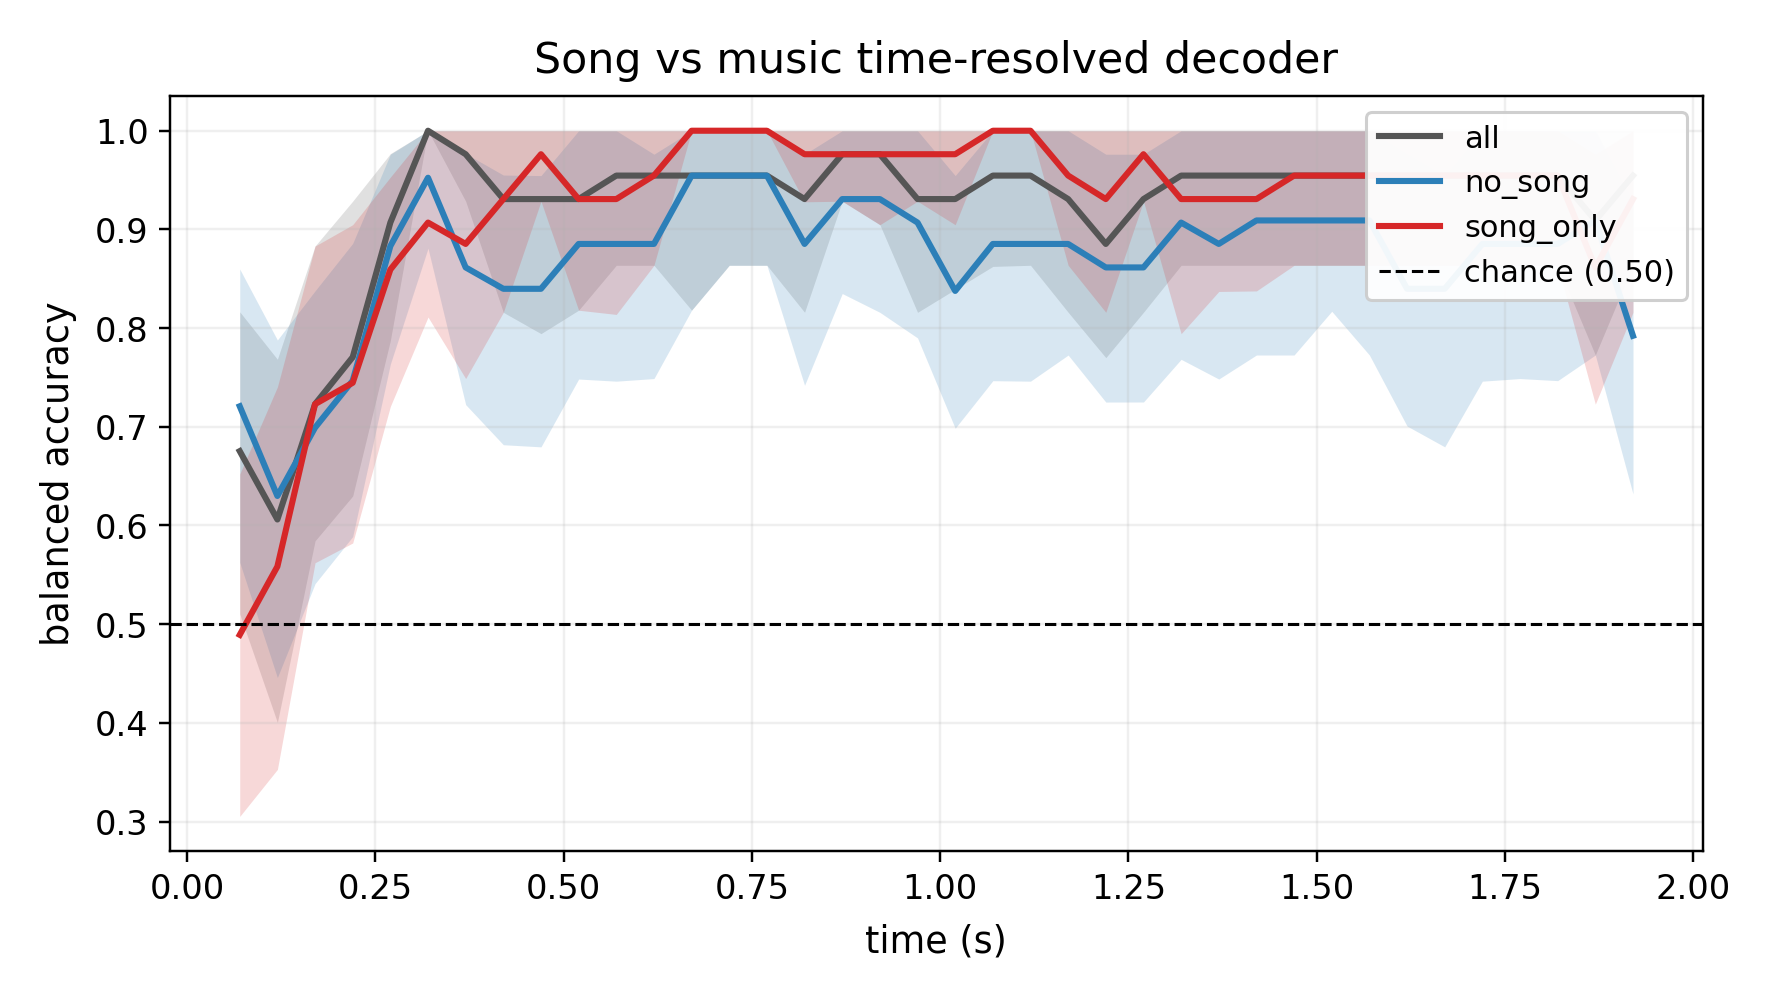

In [4]:
# Sliding-window song versus music; n_boot is the number of stimulus resamples for CIs.
t_out = pipeline.run_time_resolved_songmusic(ds, n_boot=200)
display(t_out["summary"])
display(Image(filename=str(FIG_DIR / "fig5_songmusic_time_curves.png")))
_lap("3. Time-resolved song vs music")

**Interpretation.** All three subsets support song versus music decoding. `song_only` can match or beat `no_song` in raw accuracy, but that alone does not prove specialisation because seven-electrode subsets are easier to fit. The matched null in Section 5 is the correct comparison.


## 4. RDM divergence with bootstrap and permutation (Figure 3)

**Question.** How separated are song and music in representational space, without committing to one decoder?

**Method.** RDM divergence between song and music conditions,

$$\mathcal{D}(a,b) = \text{mean\_between}(a,b) - \tfrac{1}{2}\bigl[\text{mean\_within}(a) + \text{mean\_within}(b)\bigr].$$

Per time window: bootstrap stimuli for a 95% CI, and shuffle song versus music labels 1000 times to build a null band. `p_peak` is the one-sided permutation p-value at the temporal peak.

**Readout.** Curves above their own null band indicate real song versus music geometry. Peak height for `song_only` versus `no_song` is still confounded with subset size until Section 5.


,subset,peak_divergence,peak_time_s,early_window_mean,boot_ci_lo_at_peak,boot_ci_hi_at_peak,p_peak_permutation
0,all,0.215230,1.72,0.167111,0.041160,0.202066,0.000999
1,no_song,0.108410,0.27,0.048663,0.146693,0.346547,0.003996
2,song_only,0.408296,0.37,0.299040,0.094756,0.394631,0.000999


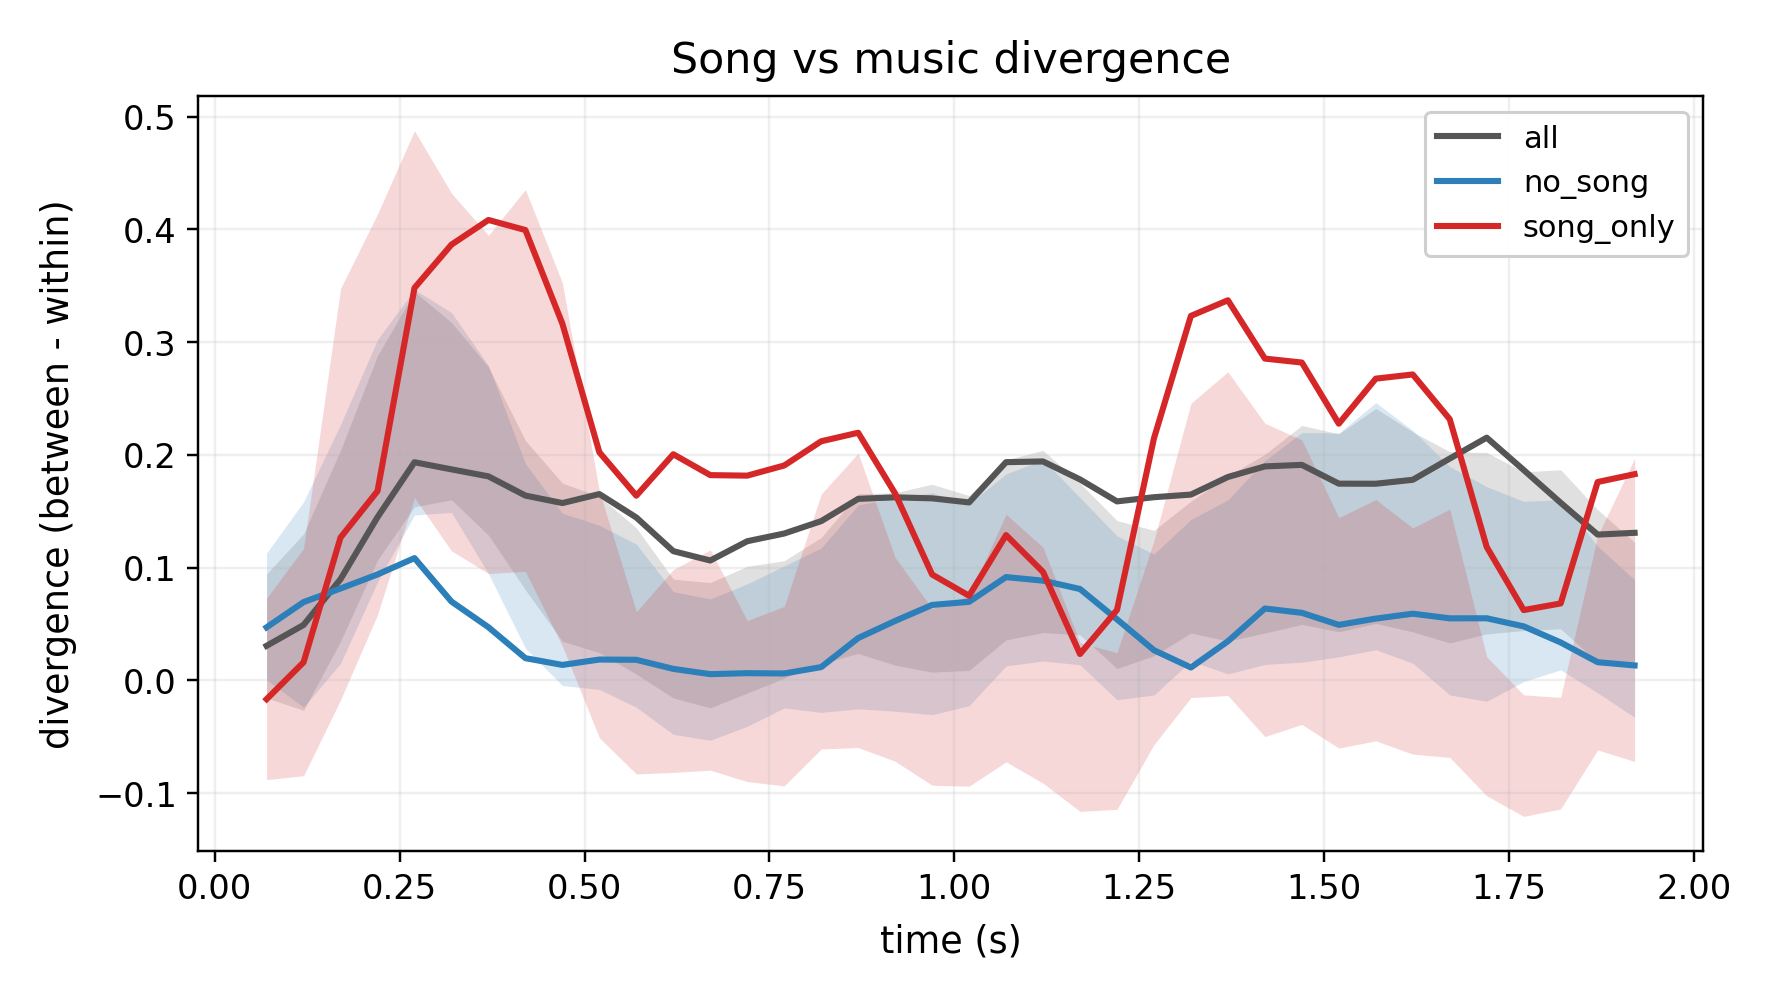

In [5]:
# RDM divergence with bootstrap and permutation bands (defaults from config).
d = pipeline.run_formalized_divergence(ds)
display(d["summary"])
display(Image(filename=str(FIG_DIR / "fig3_divergence_combined.png")))
_lap("4. Formalized divergence")

**Interpretation.** All three subsets clear their label-shuffle bands (small `p_peak`), so song versus music structure is present in each geometry. `song_only` peaks highest but is noisier because it uses only seven electrodes. Section 5 tests specialisation with a fair size-matched null.


## 4b. Acoustic-partialled divergence

**Question.** How much of the song versus music divergence is explained by the Norman–Haignere acoustic feature banks?

**Method.** Within each time window, linearly regress cochleogram (`F_coch`, 6) and spectrotemporal modulation (`F_mod`, 63) out of neural features, then compute divergence on residuals. Raw and partialled curves each get a label-shuffle null; partialled nulls refit the acoustic regression inside each shuffle.

**Readout.** `fraction_surviving_at_peak` is the partialled peak divided by the raw peak. Values near 0 mean the bank explains most of the effect. Values well above 0 with a small permutation p on the partialled curve support a residual beyond this linear acoustic model, but power is limited with 49 stimuli.


In [6]:
# Reload modules if you edited logic/*.py in another editor without restarting the kernel.
importlib.reload(data_utils)
importlib.reload(rdm)
importlib.reload(pipeline)

ap = pipeline.run_acoustic_partition(ds, n_perm=1000, ridge=1.0)
display(ap["summary"])
for name, figs in ap["figures"].items():
    print(name, "->", figs["png"].name)

_lap("4b. Acoustic partition")


  [acoustic partition] regressor 'A_full' shape=(49, 69) ridge=1.0


,subset,peak_divergence_raw,peak_divergence_partial,peak_time_raw_s,peak_time_partial_s,early_mean_raw,early_mean_partial,fraction_surviving_at_peak,p_peak_raw,p_peak_partial,n_electrodes
0,all,0.215230,0.087820,1.72,1.47,0.167111,0.068383,0.394595,0.000999,0.088911,33
1,no_song,0.108410,0.051859,0.27,0.22,0.048663,0.015403,0.469658,0.003996,0.413586,26
2,song_only,0.408296,0.191370,0.37,1.37,0.299040,0.092916,0.330720,0.000999,0.050949,7


all -> fig_acoustic_partition_all.png
no_song -> fig_acoustic_partition_no_song.png
song_only -> fig_acoustic_partition_song_only.png


**Interpretation.** Raw divergence mixes neural and acoustic differences between song and music trials. After partialling, a positive surviving fraction with a small permutation p would support structure not captured by this linear acoustic model. With 49 stimuli, partialled p-values are often borderline, so we treat that block as exploratory rather than a sharp claim about a post-acoustic code.


## 5. Matched random-subset control (Figure 4)

**Question.** After matching subset size, do the seven song-selective electrodes beat seven random electrodes drawn from the non-song pool?

**Method.** For each of two metrics (early-window balanced accuracy on song versus music, and RDM divergence on the same representation), draw many random 7-electrode subsets from `no_song`, build a null distribution, and compare the real `song_only` score. Outputs include one-sided empirical p-values and a bootstrap CI for `true minus mean(null)`.

**Readout.** A small p and a CI clearly above zero would support privilege for the song subset. A large p means the apparent advantage in Sections 3 and 4 is consistent with subset size alone.


/opt/anaconda3/envs/neuro120-tf/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/neuro120-tf/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/neuro120-tf/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/neuro120-tf/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed 

,metric,task,subset_size,n_random_subsets,true_song_only,null_mean,null_std,null_median,ref_all,ref_no_song,p_greater_vs_random,diff_ci_lo,diff_ci_median,diff_ci_hi
0,bacc,song_vs_music,7,1000,0.885281,0.856234,0.060124,0.861472,0.954545,0.906926,0.364635,0.025608,0.029123,0.032852
1,divergence,song_vs_music,7,1000,0.235823,0.197670,0.133201,0.179371,0.239878,0.212349,0.349650,0.029585,0.038313,0.046514


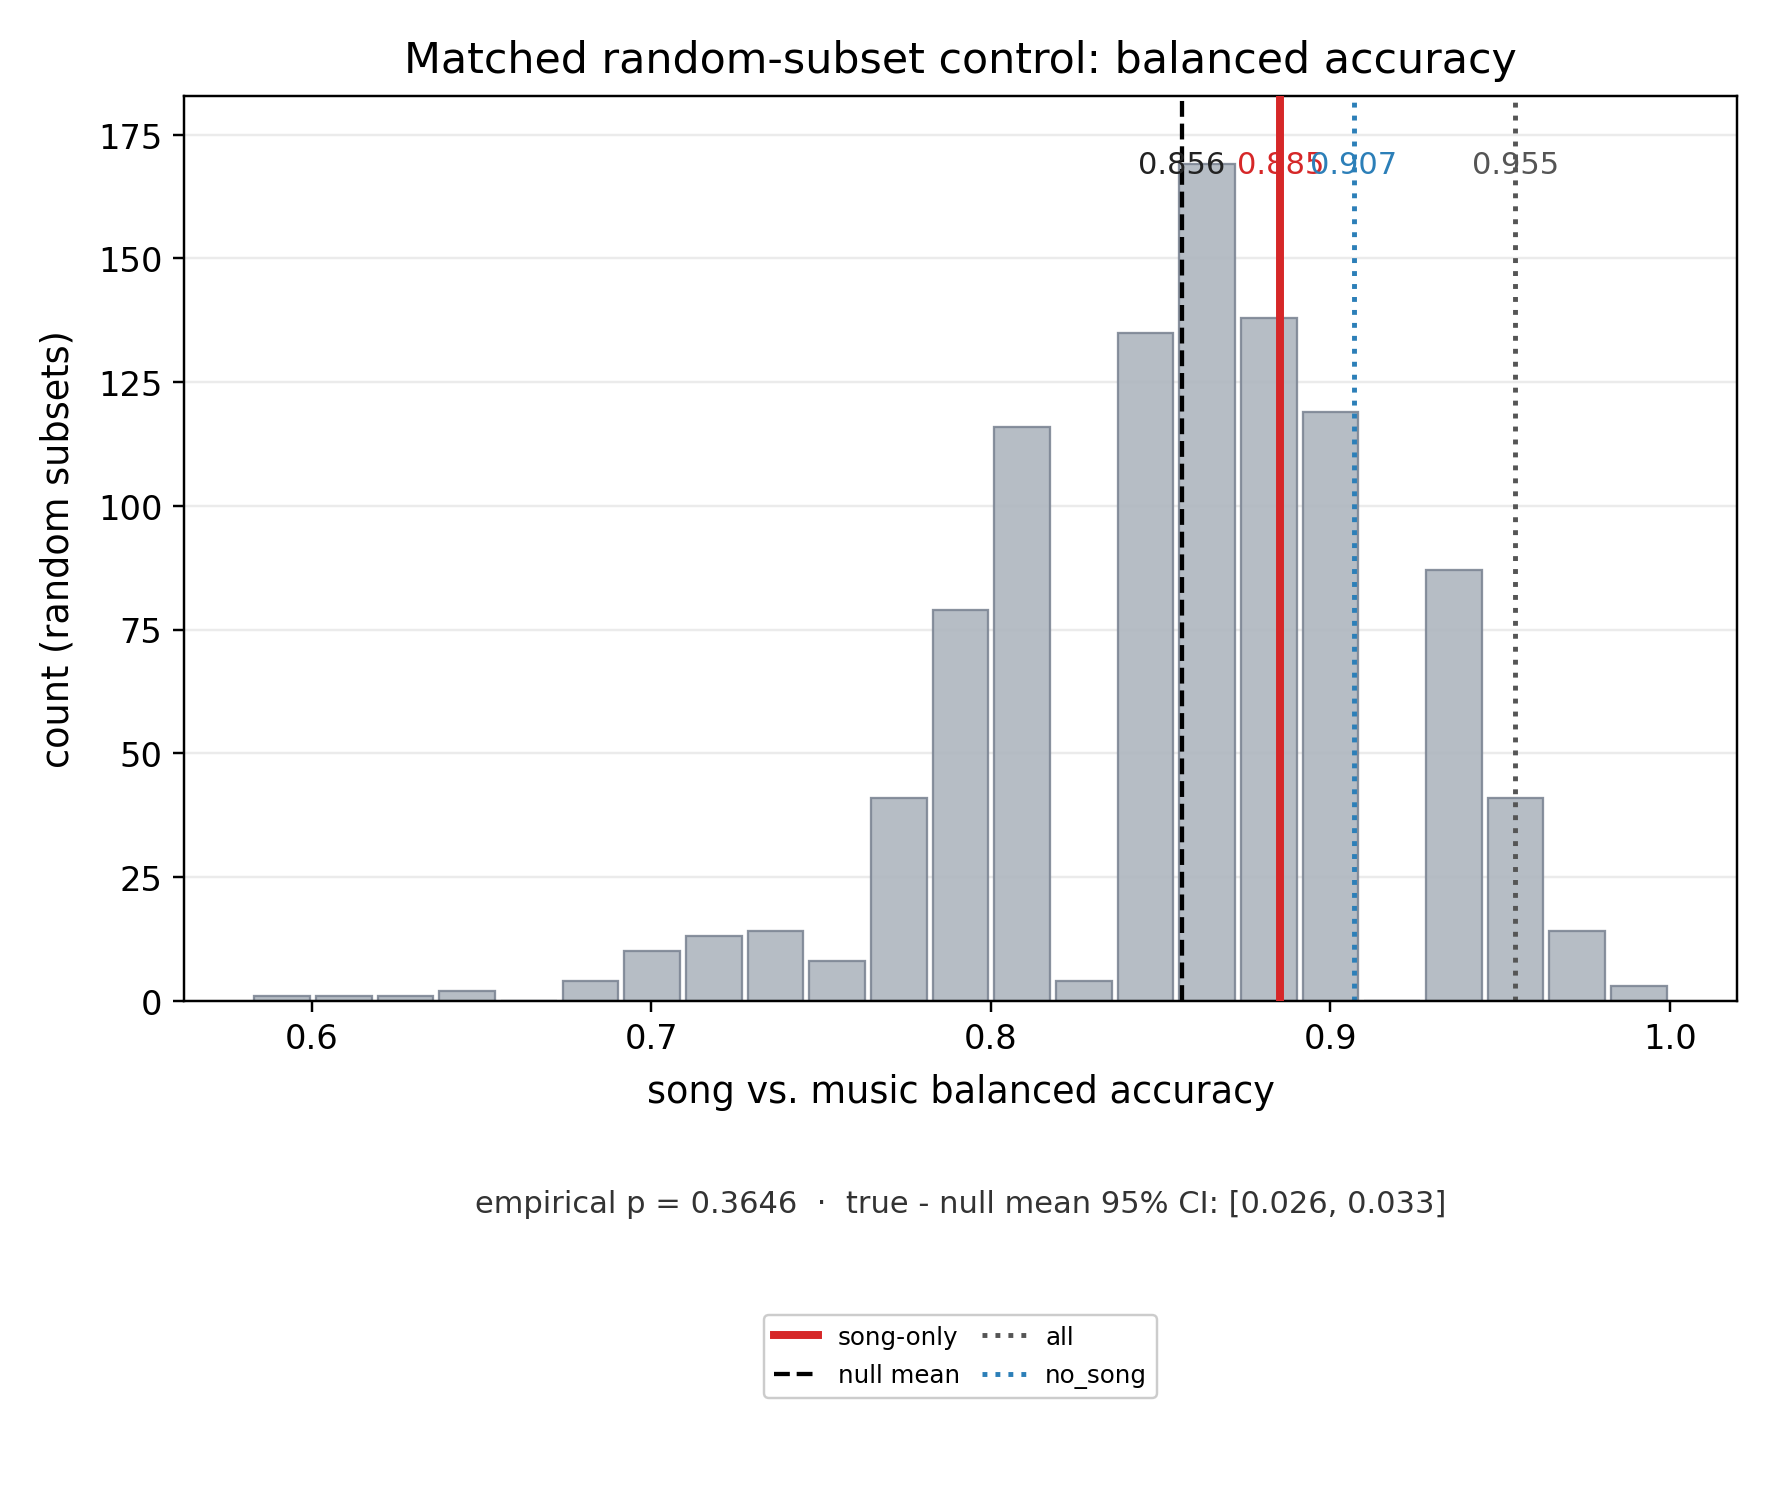

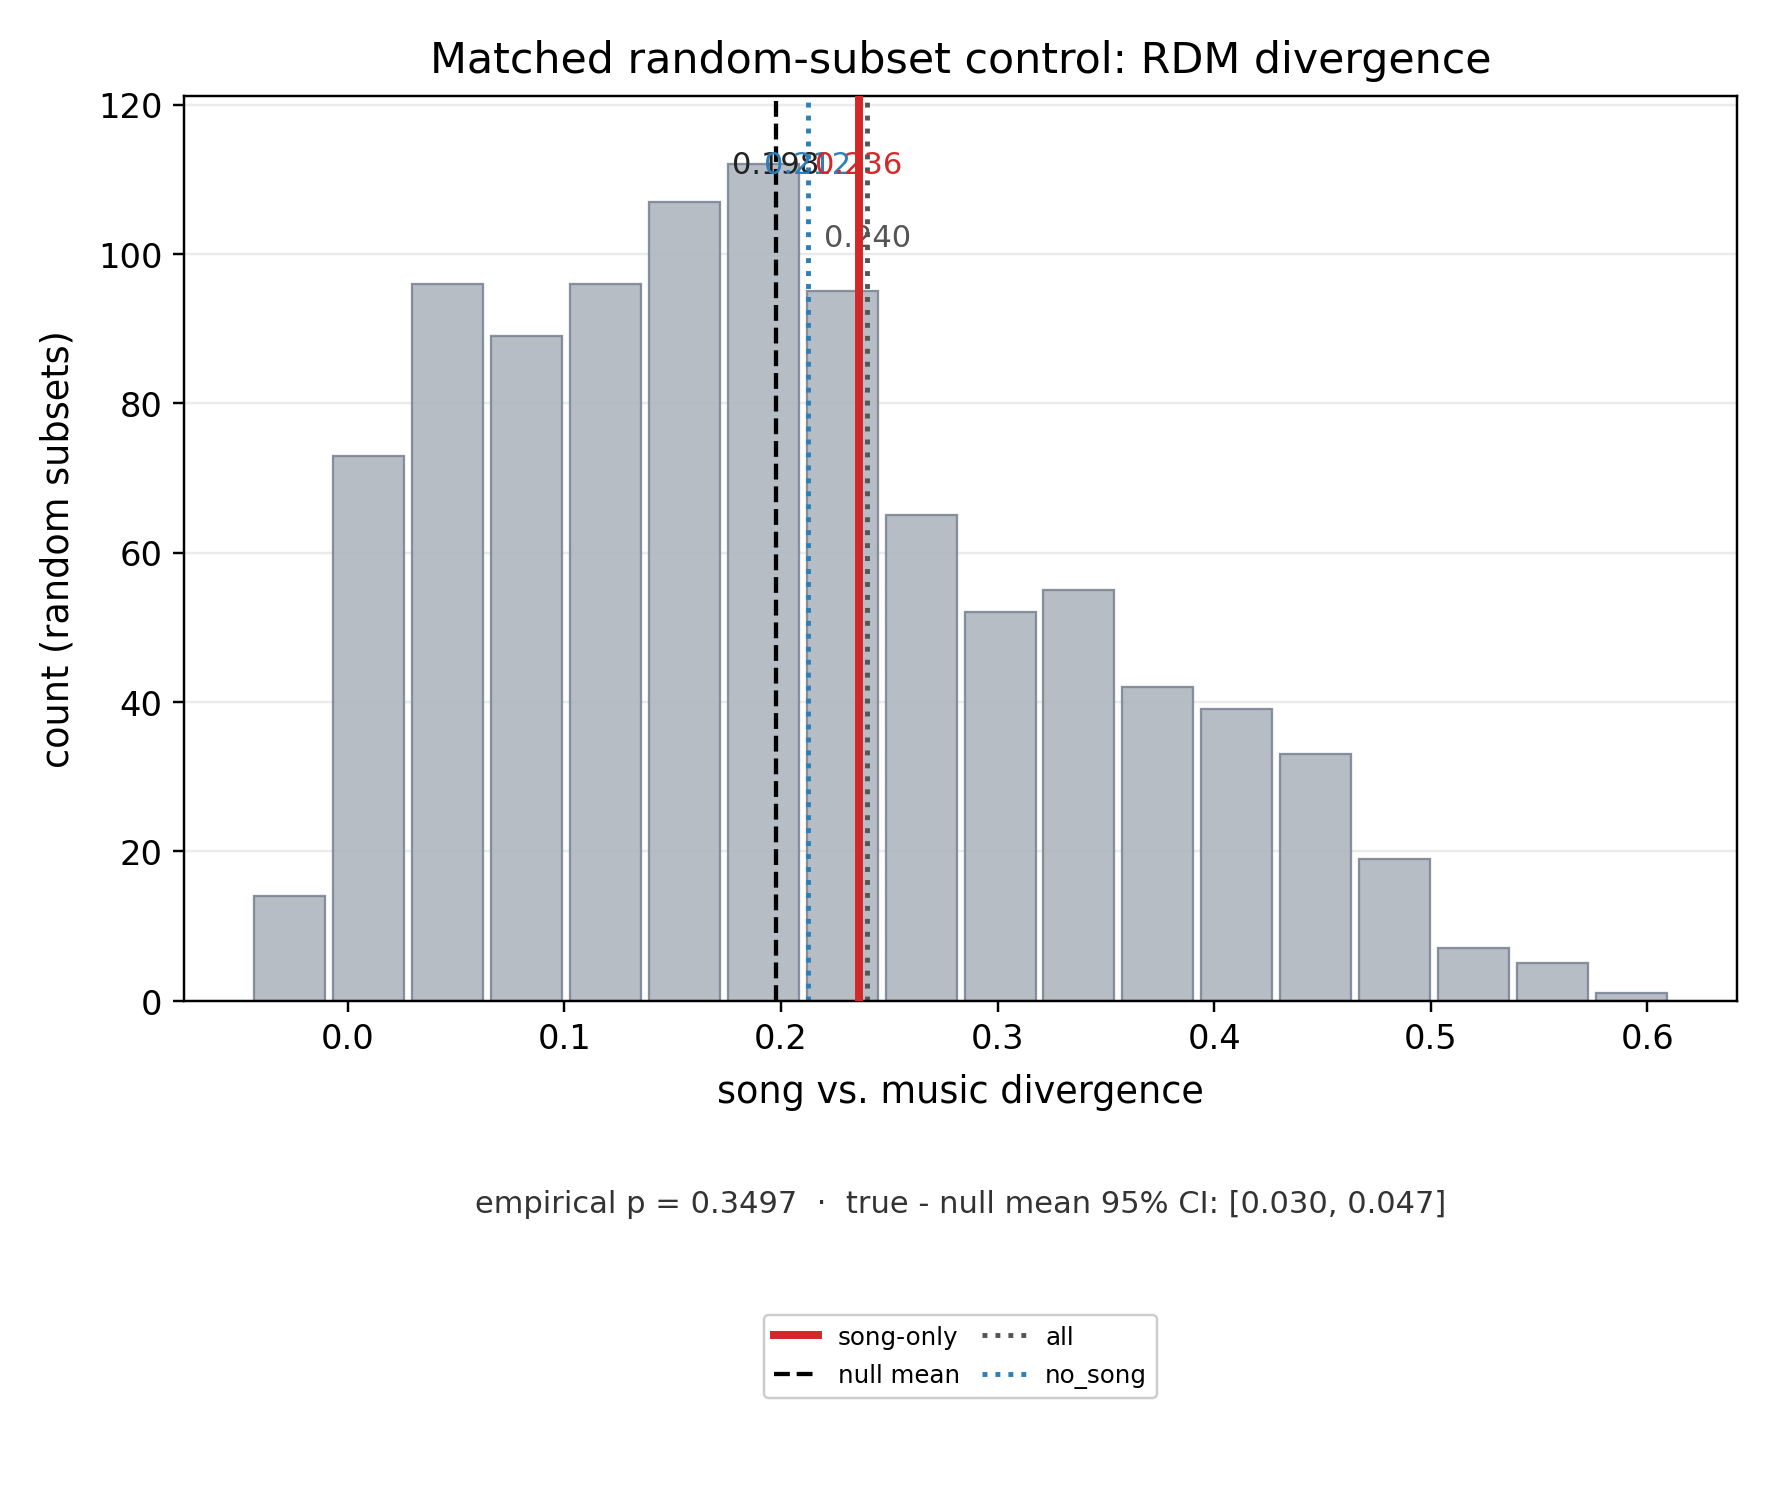

In [7]:
# Long run: use n_subsets around 1000 to 2000 for stable nulls; use 50 for a quick shape check.
# Default pipeline caching is on. Here force=True and use_cache=False rebuild the null
# and figures even if a cache entry exists (useful after code or seed changes).
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

plt.close("all")

r = pipeline.run_random_subset_control(
    ds,
    n_subsets=1000,
    force=True,
    use_cache=False,
)
display(r["summary"])

for m in ("bacc", "divergence"):
    display(
        Image(
            filename=str(FIG_DIR / f"fig4_random_subset_null_{m}.png"),
            width=900,
        )
    )

_lap("5. Random subset control")

**Balanced accuracy.** In the project outputs, `song_only` falls inside the null cloud and the CI for `song_only minus mean(null)` sits near zero, so the seven song electrodes do not beat size-matched random draws on this metric. That is the main negative result: higher raw curves for `song_only` in Section 3 are not evidence of a unique seven-electrode code.

**Divergence.** Any trend on divergence versus the null is small and does not pass a typical 0.05 threshold in the shipped tables, so representational privilege is at most weak and not established here.

**Summary.** Song-selective electrodes carry information, but they are not shown to carry more than another seven electrodes would under fair matching.


## 6. Cross-temporal generalisation (Figure 6)

**Question.** Does a song versus music decoder trained at one time generalise to other times within the trial?

**Method.** For each training time, evaluate balanced accuracy at every test time, forming an `N_t` by `N_t` matrix per subset. Summary metrics contrast on-diagonal versus far off-diagonal performance.

**Readout.** Strong off-diagonals mean a temporally stable code. Weak off-diagonals mean the representation drifts across the 2 s window.


,subset,diag_mean_bacc,offdiag_mean_bacc,max_bacc
0,all,0.920711,0.841469,1.0
1,no_song,0.869162,0.756364,1.0
2,song_only,0.917179,0.833970,1.0


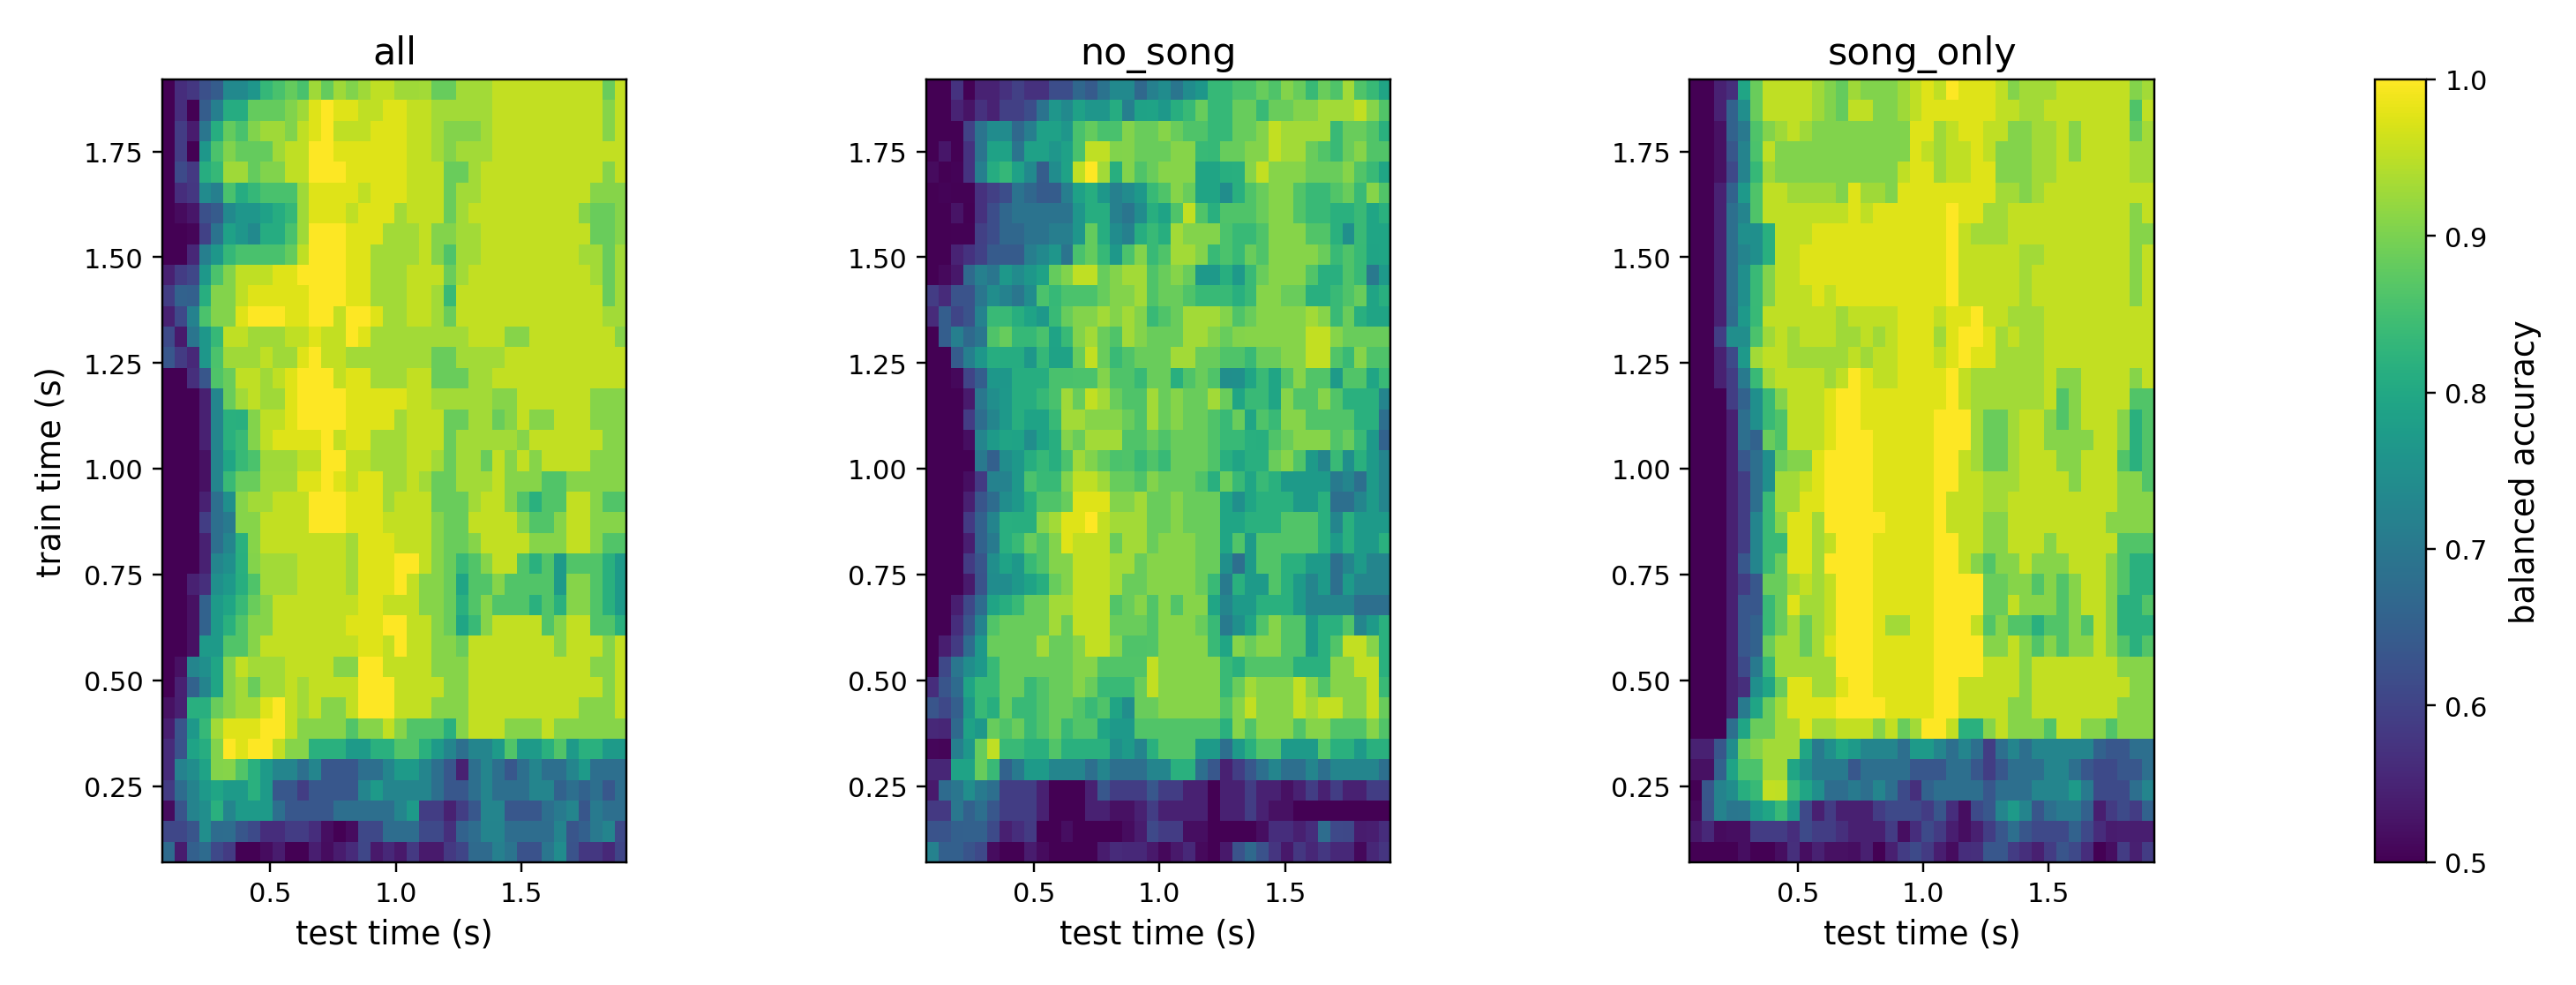

In [8]:
# Train at each time, test at all times, per subset.
c = pipeline.run_cross_temporal(ds)
display(c["summary"])
display(Image(filename=str(FIG_DIR / "fig6_cross_temporal.png")))
_lap("6. Cross-temporal")

**Interpretation.** All subsets show high on-diagonal accuracy. Off-diagonal mass stays higher for `song_only` and `all` than for `no_song`, which matches a more stable song versus music code in the song-selective set even though Section 5 showed no raw decodability privilege.


## 7. Leave-one-electrode-out contributions (Figure 7)

**Question.** When one electrode is removed, how much does song versus music performance drop, and does that drop differ by selectivity group?

**Method.** For each electrode, rerun the time-resolved song versus music analysis without it and measure the change in score. Aggregate drops by song, speech, or music selectivity and compare song to non-song with a label shuffle on groups (1000 permutations in the default pipeline call).

**Readout.** A larger mean drop for song electrodes on balanced accuracy means each song electrode contributes more on average than a typical non-song electrode, even if the seven-electrode group is not privileged in Section 5.


/opt/anaconda3/envs/neuro120-tf/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/neuro120-tf/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/neuro120-tf/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/neuro120-tf/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed 

,electrode_group,mean_delta_bacc,std_delta_bacc,mean_delta_divergence,n,perm_p_song_vs_rest_bacc
0,music,0.000352,0.003278,0.004899,11,0.227772
1,song,0.000789,0.002613,0.001667,7,0.227772
2,speech,-0.000414,0.003152,-0.003893,15,0.227772


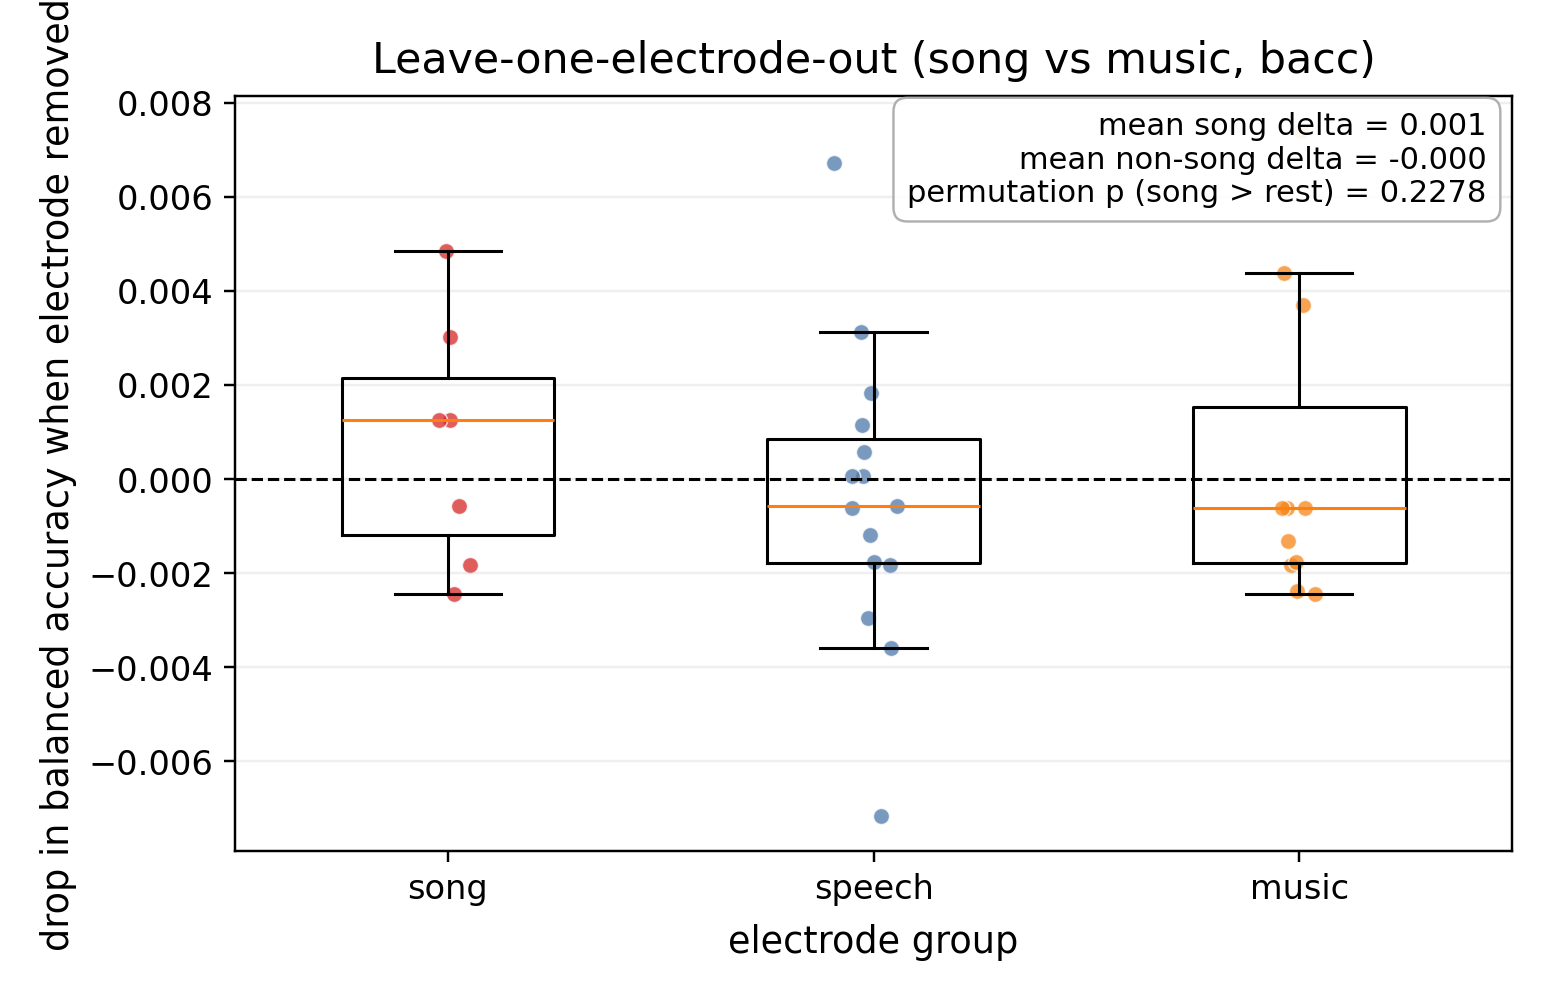

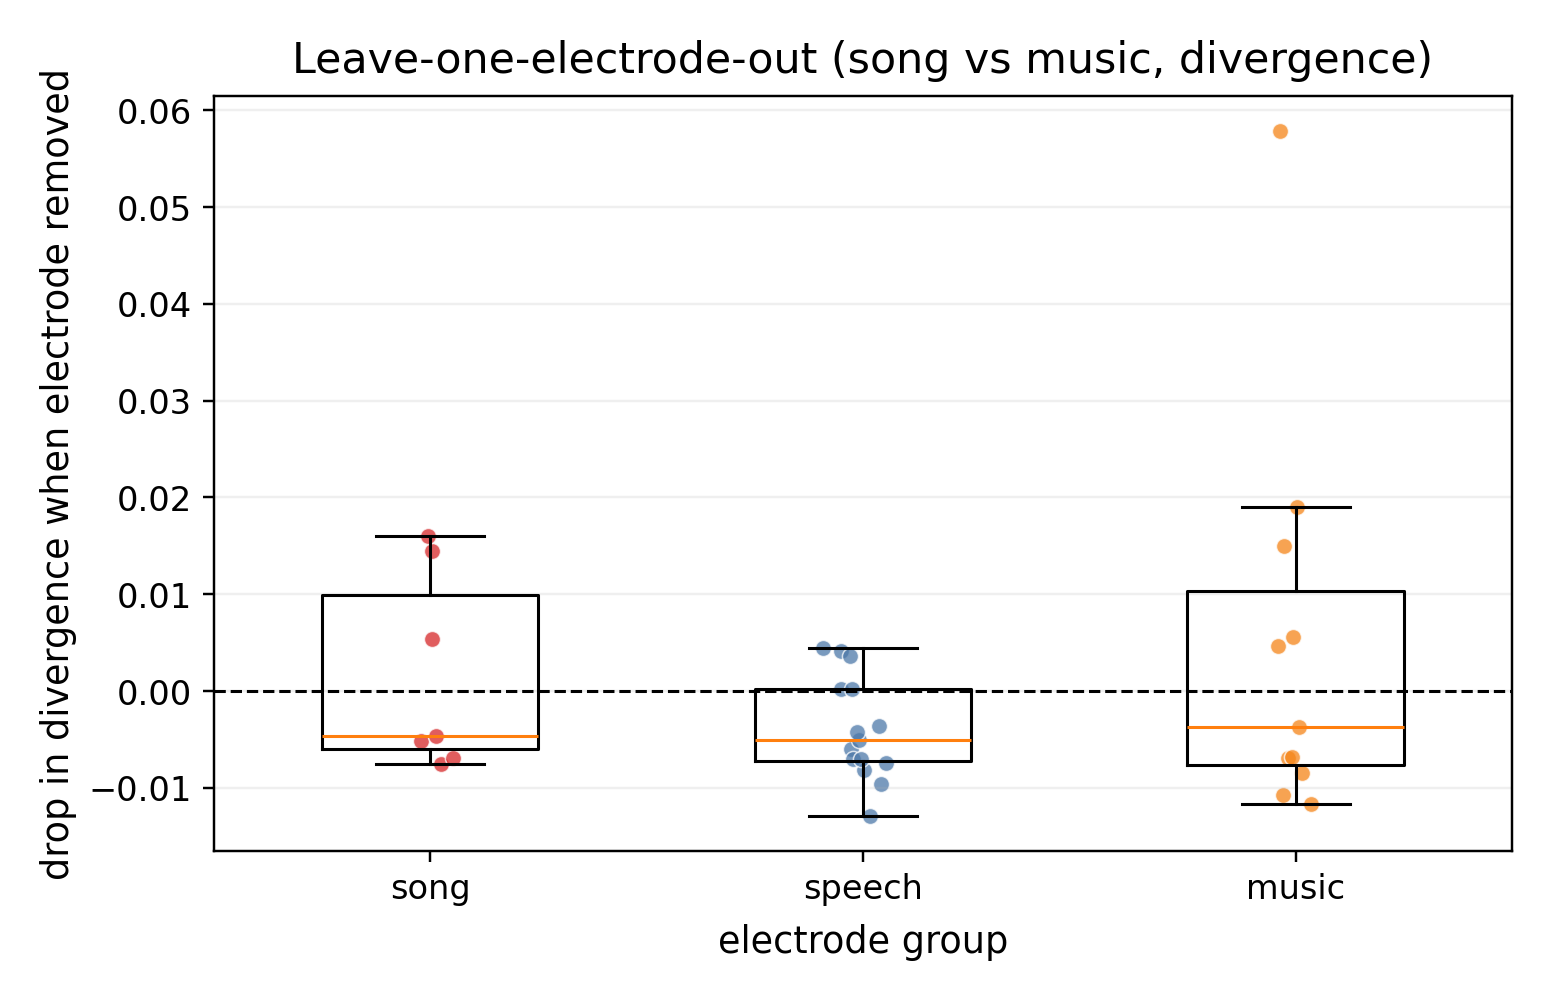

In [9]:
# Leave-one-electrode-out drops with group permutation on balanced accuracy and divergence.
l = pipeline.run_loo_clean(ds, n_perm=1000)
display(l["group_summary"])
display(Image(filename=str(FIG_DIR / "fig7_loo_contributions_bacc.png")))
display(Image(filename=str(FIG_DIR / "fig7_loo_contributions_divergence.png")))
_lap("7. LOO contributions")

**Interpretation.** On balanced accuracy, per-electrode drops are largest for the song group and the group contrast is significant in the shipped run. On divergence, groups are more similar. Together with Section 5, the story is that the seven electrodes are not jointly special on matched nulls, but individual song electrodes still carry more marginal weight than individual non-song electrodes.


## 8. Nonlinear baselines

**Question.** Do nonlinear models improve song versus music decoding enough to matter?

**Method.** Same grouped folds and early-window features as the linear baselines, with an RBF SVM and a frozen autoencoder plus logistic head, for three-class and binary tasks.

**Readout.** If nonlinear models do not beat logistic regression, the linear analyses are not missing a large nonlinear effect at this sample size.


,task,model,bacc,macro_f1,fold_bacc_std,recall_music,recall_song,recall_speech
0,song_vs_music_all_electrodes,autoencoder_latent_logreg,0.954545,0.964563,0.100000,1.000000,0.909091,NaN
1,song_vs_music_all_electrodes,linear_logreg,0.954545,0.964563,0.100000,1.000000,0.909091,NaN
2,song_vs_music_all_electrodes,rbf_svm,0.954545,0.964563,0.100000,1.000000,0.909091,NaN
3,three_class_all_electrodes,autoencoder_latent_logreg,0.923521,0.926984,0.105409,0.952381,0.818182,1.0
4,three_class_all_electrodes,linear_logreg,0.969697,0.974603,0.066667,1.000000,0.909091,1.0
5,three_class_all_electrodes,rbf_svm,0.969697,0.976375,0.066667,1.000000,0.909091,1.0


,task,model,delta_bacc_vs_linear
0,song_vs_music_all_electrodes,autoencoder_latent_logreg,0.000000
1,song_vs_music_all_electrodes,rbf_svm,0.000000
2,three_class_all_electrodes,autoencoder_latent_logreg,-0.046176
3,three_class_all_electrodes,rbf_svm,0.000000


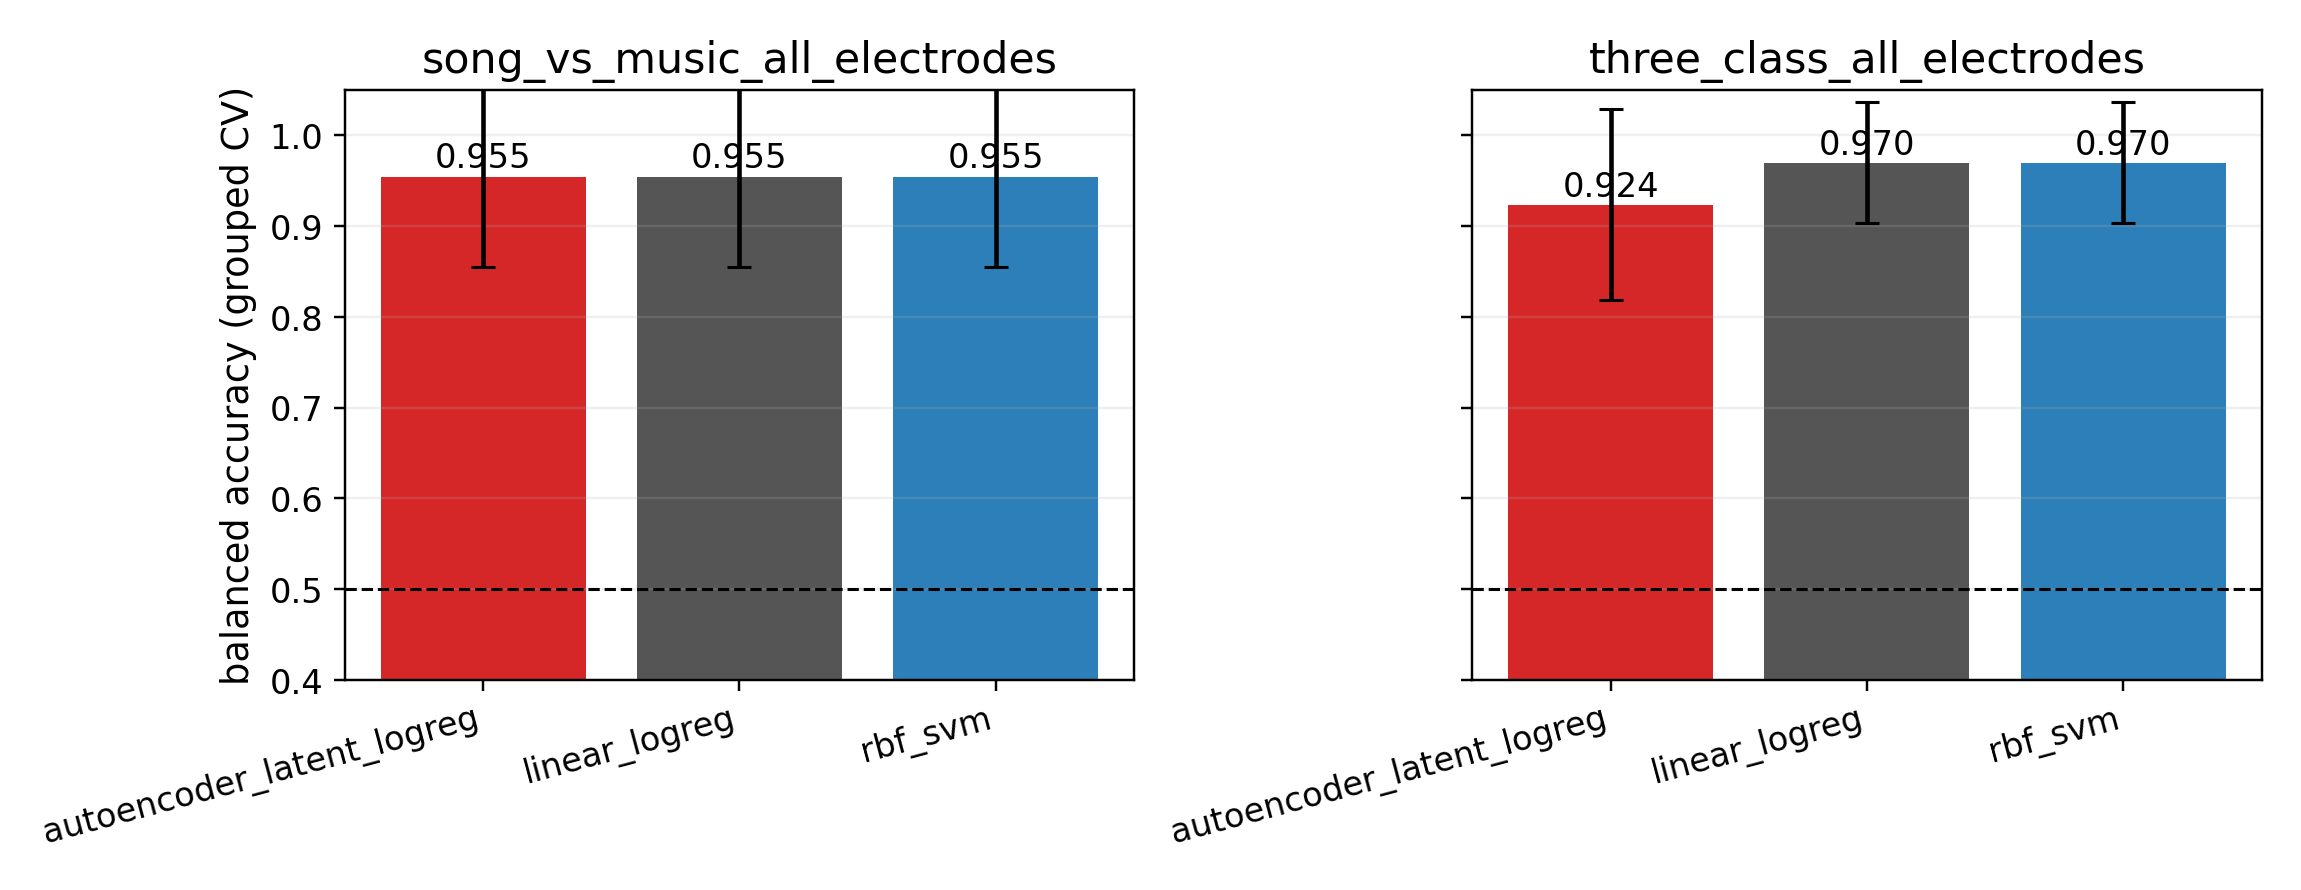

In [10]:
# RBF SVM and autoencoder plus logistic head versus linear baselines.
nl = pipeline.run_nonlinear_supplement(ds)
display(nl["summary"])
display(nl["delta_vs_linear"])
display(Image(filename=str(FIG_DIR / "fig_nonlinear_comparison.png")))
_lap("8. Nonlinear supplement")

**Interpretation.** In the shipped results, nonlinear models do not beat the linear baseline by a meaningful margin. With 49 stimuli, that is expected. The main paper therefore sticks to linear decoders and RDM analyses.


## 9. Bellier (2023) extension: vocal versus instrumental decoder (Figure 8)

**Question.** Does a decoding story similar to Norman–Haignere still make sense on one long naturalistic song?

**Method.** Build a supergrid of HFA from 29 patients (Bellier et al., 2023) at 100 Hz for the published clip length. Use 500 ms windows every 100 ms, label windows by whether the vocal mask covers more than half of the window, and fit blocked-time 5-fold logistic regression on subsets of electrodes. A small temporal CNN runs only when linear accuracy exceeds chance by a fixed margin in `config`.

**Files.** Audio `data/bellier_2023/audio/thewall1.wav` should match neural length at 100 Hz. Vocal timing lives in `data/bellier_2023/audio/vocal_segments.csv` with columns `start_s` and `end_s`; overlapping rows are merged when building the mask.

**Readout.** Bellier report stronger responses for vocal content in right STG than left STG. In the summary table, compare `right_STG`, `left_STG`, `non_STG`, and `all`. High `all` means the signal is spread across the pool, not only STG.


**Sanity check.** The next cell prints WAV length, neural length at 100 Hz, whether they match, and a short summary of the vocal mask. Confirm durations agree and that merged vocal intervals look reasonable before you run the decoder cell.


In [11]:
# Check that the published WAV length matches the neural T at 100 Hz, then print mask coverage.
with wave.open(str(BELLIER_AUDIO_PATH), "rb") as w:
    wav_dur = w.getnframes() / w.getframerate()
neural_dur = BELLIER_T / BELLIER_FS
print(f"WAV duration: {wav_dur:.3f} s ({BELLIER_AUDIO_PATH.name})")
print(f"Neural duration: {neural_dur:.3f} s (T={BELLIER_T} at {BELLIER_FS} Hz)")
print(f"Aligned within 10 ms: {np.isclose(wav_dur, neural_dur, atol=0.01)}")

mask = load_vocal_segments()
diff = np.diff(mask.astype(int))
starts = np.where(diff == 1)[0] + 1
ends = np.where(diff == -1)[0] + 1
if mask[0]:
    starts = np.r_[0, starts]
if mask[-1]:
    ends = np.r_[ends, len(mask)]
print(f"\nVocal CSV: {BELLIER_VOCAL_CSV.name}")
print(f"Vocal samples: {int(mask.sum())} / {len(mask)} ({mask.mean()*100:.2f}%)")
print(f"Merged intervals: {len(starts)}")
for s, e in zip(starts, ends):
    print(
        f"  {s/BELLIER_FS:7.3f} to {e/BELLIER_FS:7.3f} s "
        f"(duration {(e-s)/BELLIER_FS:.3f} s)"
    )

_lap("9a. Bellier alignment check")


WAV duration: 190.720 s (thewall1.wav)
Neural duration: 190.720 s (T=19072 at 100 Hz)
Aligned within 10 ms: True

Vocal CSV: vocal_segments.csv
Vocal samples: 5803 / 19072 (30.43%)
Merged intervals: 4
   15.080 to  16.900 s (duration 1.820 s)
   17.460 to  19.150 s (duration 1.690 s)
   24.410 to  29.570 s (duration 5.160 s)
   42.660 to  92.020 s (duration 49.360 s)


In [12]:
# Blocked-time CV on the supergrid; may take a while on CPU. Uses config seeds and paths.
bd = pipeline.run_bellier_decoder()
display(bd["summary"])
_lap("9b. Bellier decoder")

  P1: kept 55 / dropped 9
  P2: kept 57 / dropped 7
  P3: kept 48 / dropped 16
  P4: kept 87 / dropped 12
  P5: kept 84 / dropped 9
  P6: kept 82 / dropped 1
  P7: kept 94 / dropped 7
  P8: kept 60 / dropped 16
  P9: kept 97 / dropped 12
  P10: kept 94 / dropped 3
  P11: kept 78 / dropped 18
  P12: kept 110 / dropped 1
  P13: kept 85 / dropped 9
  P14: kept 40 / dropped 18
  P15: kept 114 / dropped 6
  P16: kept 57 / dropped 3
  P17: kept 50 / dropped 9
  P18: kept 119 / dropped 9
  P19: kept 79 / dropped 19
  P20: kept 64 / dropped 7
  P21: kept 80 / dropped 29
  P22: kept 123 / dropped 11
  P23: kept 91 / dropped 7
  P24: kept 57 / dropped 3
  P25: kept 74 / dropped 2
  P26: kept 80 / dropped 1
  P27: kept 36 / dropped 0
  P28: kept 62 / dropped 17
  P29: kept 238 / dropped 12
  [decoder] subset=all        n_elec= 2395 n_wins= 1903 pos_rate=0.304
    logreg  bacc=0.777 CI=[0.733, 0.775]
[bellier_decoder] PyTorch device for CNN: mps (set NEURO120_DEVICE=cpu|cuda|mps|auto)
    cnn     

,subset,model,n_elec,n_windows,mean_bacc,mean_auc,bacc_ci95_low,bacc_ci95_high
0,all,logreg,2395,1903,0.777221,0.898513,0.732684,0.774973
1,all,cnn,256,1903,0.768237,0.839147,0.726354,0.768737
2,right_STG,logreg,181,1903,0.691743,0.813844,0.655260,0.695529
3,right_STG,cnn,181,1903,0.730344,0.838188,0.699776,0.743306
4,left_STG,logreg,245,1903,0.684201,0.780020,0.667463,0.713514
5,left_STG,cnn,245,1903,0.727247,0.807228,0.706353,0.749391
6,non_STG,logreg,1969,1903,0.730001,0.892442,0.698653,0.742620
7,non_STG,cnn,256,1903,0.732427,0.824985,0.693063,0.737444


**Interpretation.** Compare subset rows to the pattern right STG strongest, then left STG, then non-STG, as in Bellier et al. If `right_STG` leads, that matches their lateralisation story on a vocal versus instrumental label. If `all` is as high as STG rows, the decoder is using signal spread across the grid. If STG rows are high and `non_STG` is near chance, that supports a concentration in higher-order auditory cortex for this task.

The CNN column matters only when it runs: a small gain over logistic regression on windowed HFA is normal and is not a failed replication by itself.


## 10. Cross-dataset temporal profiles (Figures 9 and 10)

**Question.** Do Norman–Haignere song-selective electrodes and Bellier right STG vocal responses have a similar time course?

**Method.** Build event-aligned or trial-aligned HFA profiles in a shared schema. Bellier averages within anatomical groups and locks to vocal or instrumental onsets. Norman–Haignere averages within selectivity groups and across stimuli per class on the trial clock. Each profile row includes:

- `peak_latency_s`: time of the maximum between 0 and 1.0 s.
- `onset_sustained_ratio`: mean HFA from 0 to 0.2 s divided by mean from 0.5 to 1.5 s. Values below 1 indicate sustained responses.
- `auc`: integral of HFA from 0 to 1.5 s within each dataset only, because absolute scaling differs across studies.

Figure 10 overlays peak-normalised Bellier right STG on vocal onsets with Norman song electrodes on song trials. This is a qualitative shape comparison, not a formal statistical test.


In [13]:
# Reload if you edited temporal_profile.py or pipeline.py without restarting the kernel.
importlib.reload(temporal_profile)
importlib.reload(pipeline)

bp = pipeline.run_bellier_profiles(ds_norman=ds)
display(bp["combined_features"])
_lap("10. Bellier profiles")

,dataset,group,event,n_elec,n_events,peak_latency_s,onset_sustained_ratio,auc
0,bellier,right_STG,vocal,181,4,0.06,1.574431,0.229335
1,bellier,right_STG,instrumental,181,4,0.49,1.304758,0.123119
2,bellier,left_STG,vocal,245,4,0.02,1.106680,0.200850
3,bellier,left_STG,instrumental,245,4,0.61,1.148878,0.114978
4,norman,song,song,7,11,0.66,0.105786,100.752086
5,norman,song,music,7,21,0.40,0.437313,34.720332
6,norman,song,speech,7,17,0.22,0.532998,35.552592
7,norman,music,song,11,11,0.65,0.187412,97.572953
8,norman,music,music,11,21,0.37,0.431150,82.081461
9,norman,music,speech,11,17,0.25,0.581898,26.266018


**Interpretation.** Focus on `onset_sustained_ratio` and the overlaid curves. If Bellier `right_STG__vocal` and Norman `song__song` are both below 1 and look similar in time, that supports a shared sustained component. If Norman song traces are more transient than Bellier right STG, the two paradigms stress different temporal regimes and that contrast is still a valid result. Figures and the feature table are the full output for this section.


## 10.5 Bellier supergrid indices for subset analyses

The supplement notebook builds matched-null comparisons on Bellier data. Those calls need an explicit index vector for the focal subset. The cell below builds the cached supergrid, takes up to seven right STG electrode indices, and displays them. It is a small reference block, not a full rerun of the Norman pipeline on Bellier.


In [14]:
# Uncomment to print which Python binary this kernel is using.
# import sys
# print(sys.executable)
_lap("10.5a Optional interpreter cell")


In [15]:
from bellier_data import build_supergrid, electrode_subsets

# Example focal subset: first min(7, n) right STG indices in the supergrid column order.
supergrid = build_supergrid(cache=True, verbose=False)
rh = electrode_subsets(supergrid)["right_STG"]
k = int(min(7, rh.size))
true_subset = rh[:k]
display(true_subset)
_lap("10.5b Supergrid subset indices")


array([ 0,  1,  5,  6,  9, 10, 14])

## 11. Final takeaways

Use the tables and figures above as the primary record. This list states the conclusions they support in plain language.

- **Decoding quality.** Three-class decoding is strong in the early window. Song versus music curves reach very high balanced accuracy for `all`, `no_song`, and `song_only`.
- **Geometry.** All three subsets clear their own label-shuffle bands on RDM divergence, so song versus music structure is not a labelling artefact.
- **Matched null.** On balanced accuracy, `song_only` does not beat seven random non-song electrodes under fair matching. On divergence the evidence for privilege is at most weak. The gap between `song_only` and `all` in raw Section 3 curves is therefore consistent with subset size, not with a unique seven-electrode code.
- **Acoustic control.** After linear acoustic partialling, a fraction of the divergence peak remains, but partialled permutation p-values are noisy at N equals 49. Treat that block as exploratory.
- **Single-electrode leverage.** Leave-one-out drops are larger on average for song-labelled electrodes than for others on balanced accuracy, even though the seven-electrode group is not special under matching.
- **Temporal stability.** Cross-temporal matrices show more off-diagonal mass for `song_only` and `all` than for `no_song`, which fits a more stable song versus music code in song-selective electrodes.
- **Nonlinear baselines.** RBF SVM and autoencoder plus logistic regression do not clearly beat logistic regression here.
- **Bellier decoder.** Vocal versus instrumental decoding sits above chance on the supergrid, with ordering across subsets broadly consistent with Bellier et al.
- **Bellier versus Norman shapes.** Bellier right STG vocal traces look more transient than Norman song-selective trial averages, so the two studies highlight different temporal regimes.

**Bottom line.** Song-selective electrodes are informative and somewhat stronger per electrode, and their code is more stable in time, but the matched null shows they are not jointly privileged on decoder extractable information relative to other seven-electrode draws from the non-song pool.

Caches live under `results/` (including `results/cache/` and `results/metrics.json` after a full `pipeline.run_all`). Rerun this notebook from the top after code or data changes if you need a full refresh.


## Timing summary

In [ ]:
print_run_timings()


Section run times (wall clock)
  1. Setup and dataset load                         0.18 s
  Figure 1 dataset overview                         0.37 s
  2. Baseline three-class                           0.02 s
  3. Time-resolved song vs music                   14.53 s
  4. Formalized divergence                         13.80 s
  4b. Acoustic partition                           14.69 s
  5. Random subset control                          4.07 s
  6. Cross-temporal                                 6.50 s
  7. LOO contributions                              4.72 s
  8. Nonlinear supplement                           1.60 s
  9a. Bellier alignment check                       0.03 s
  9b. Bellier decoder                             104.07 s
  10. Bellier profiles                              1.74 s
  10.5a Optional interpreter cell                   0.03 s
  10.5b Supergrid subset indices                    1.16 s
  --------------------------------------------------------
  Total                 